<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-257-Machine-Learning/blob/main/W5S1_SU26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CMPE-257, Machine Learning, Summer 2026
## Week 5: Overfitting, Regularization, Validation

In this workbook, you will be gaining experience on the practice of ML by experimenting with:

- subset selection methods
- regularization methods
- applying cross-validation

In [3]:
# YOUR NAME: <Meenakshi Rajpurohit>

In [4]:
# loads required modules
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

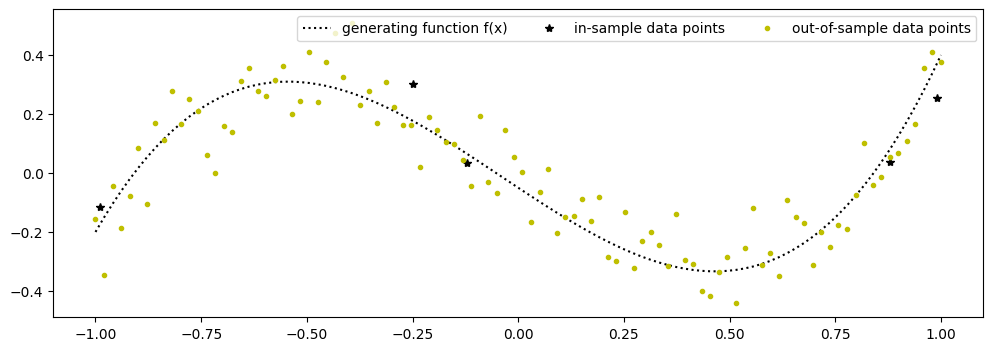

In [5]:
# Loads and plots the dataset "w5_data.pkl" to be used in Parts 1 and 2
# The dataset is given in two dataframes data[0] and data[1] corresponding to the in-sample set (5 data samples)
# and out-of-sample set (100 data samples), respectively. Each dataframe contains 11 columns: a real-valued index
# (idx), eight predictors (p0,p1,...'p7), the noisless target (f), and the noisy target/observations (y)

with open("w5_data.pkl", "rb") as file:
    data = pickle.load(file)

fig, ax = plt.subplots(1,1,figsize=(12,4))
ax.plot(data[1]['idx'].values,data[1]['f'].values,':k',label='generating function f(x)')
ax.plot(data[0]['idx'].values,data[0]['y'].values,'*k',label='in-sample data points')
ax.plot(data[1]['idx'].values,data[1]['y'].values,'.y',label='out-of-sample data points')
ax.legend(ncol=3)
plt.show()

In [6]:
# The following function is used to conduct linear regressions by using either the LinearRegression, Ridge,
# or Lasso classes in scikit learn. It admits the following input parmeters:
# datasets: a two element array of dataframes containing the in-sample and out-of-sample data sets
# variables: a list with the column names (from dataset dataframes) to be used as preditors in the regression
# regtype: the regression algorithm to be used (i.e. 'linear', 'ridge' or 'lasso')
# alpha (lambda): the shrinkage factor (only used in 'ridge' and 'lasso'), if zero then 'linear' is used
# verbose: a boolean flag to display the obtained coefficients, regression errors and R2 score
# plot: a boolean flag to plot the data and the resulting model curve (out-of-sample predictions)

def do_regression(datasets,variables,regtype='linear',alpha=0.0,verbose=False,plot=False):
    result = {}
    in_X = datasets[0][variables].to_numpy()
    in_Y = datasets[0]['y'].to_numpy()
    if alpha==0.0 or regtype=='linear':
        reg = LinearRegression(fit_intercept=False).fit(in_X,in_Y)
    elif regtype=='ridge':
        reg = Ridge(alpha=alpha,fit_intercept=False).fit(in_X,in_Y)
    elif regtype=='lasso':
        reg = Lasso(alpha=alpha,fit_intercept=False).fit(in_X,in_Y)

    in_pred = reg.predict(in_X)
    in_err = mean_squared_error(in_Y, in_pred)
    out_X = datasets[1][variables].to_numpy()
    out_Y = datasets[1]['y'].to_numpy()
    out_pred = reg.predict(out_X)
    out_err = mean_squared_error(out_Y, out_pred)
    out_r2 = reg.score(out_X,out_Y)

    result['model']=reg
    result['type']=regtype
    result['alpha']=alpha
    result['coefficients']=reg.coef_
    result['intercept']=reg.intercept_
    result['in_error']=in_err
    result['out_error']=out_err
    result['out_r2']=out_r2
    result['curve']=out_pred

    if verbose:
        print(regtype[0].upper()+regtype[1:]+' Regression (alpha = '+str(alpha)+')')
        print('Coefficients: '.rjust(21),end='')
        print(', '.join(['{:8.6f}'.format(x) for x in reg.coef_]))
        print('Intercept: '.rjust(21),end='')
        print(reg.intercept_)
        print('In-sample Error: '.rjust(21)+str(in_err))
        print('Out-of-sample Error: '.rjust(21)+str(out_err))
        print('Out-of-sample R2: '.rjust(21)+str(out_r2))

    if plot:
        fig, ax = plt.subplots(1,1,figsize=(12,4))
        ax.plot(datasets[1]['idx'].values,datasets[1]['f'].values,':k',label='generating function f(x)')
        ax.plot(datasets[1]['idx'].values,out_pred,'-b',label='estimated function g(x)')
        ax.plot(datasets[0]['idx'].values,in_Y,'*k',label='in-sample data points')
        ax.plot(datasets[1]['idx'].values,out_Y,'.y',label='out-of-sample data points')
        ax.legend(ncol=2)

    return result

Linear Regression (alpha = 0.0)
       Coefficients: 0.090966, -0.108906, 0.056328, 0.430303, -0.380836, -0.236193, 0.334116, 0.123550
          Intercept: 0.0
    In-sample Error: 8.228535687394465e-32
Out-of-sample Error: 0.04686603714134424
   Out-of-sample R2: 0.147241658339332


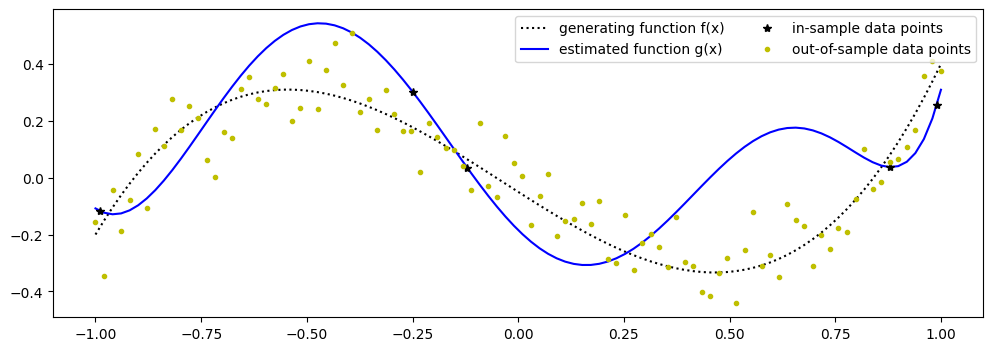

In [7]:
# Excercise #1: perform a baseline linear regression by using all predictors (p0, p1, ... p7) in the dataset

allvars = [x for x in data[0].columns if 'p' in x]
model_baseline = do_regression(data,allvars,verbose=True,plot=True)

In [8]:
# How results in exercise #1 compare to the ones presented in class? Does the model overfits the data? Why?
#<Results closely match the ones presented in class: in-sample error ~8.23e-32 (numerically zero) and out-of-sample error ~0.046866, with out-of-sample R² = 0.147. Yes, the model significantly overfits. With only 5 in-sample data points and 8 free coefficients, the regression has more than enough degrees of freedom to interpolate the data exactly, including the noise, rather than learning the true underlying function f(x). >

## PART 1: Subset Selection Methods

In [9]:
# Exercise #2: implement a loop for computing linear regressions on all possible combinations of predictors,
# group the models according to the number of predictors used and generate a tabular representation showing
# only the model in each group exhibiting the smalest out-of-sample error. Include the following five fields
# in the table: model description (i.e. specific predictors used in the model), number of predictors, in-sample
# error, out-of-sample error, out-of-sample R2 score.

models_all = []
for n in tqdm(range(1,len(allvars)+1)):
    for subset in combinations(allvars,n):
        r = do_regression(data,list(subset))
        models_all.append({'model':'{'+', '.join(subset)+'}',
                           '#predictors':n,
                           'in_error':r['in_error'],
                           'out_error':r['out_error'],
                           'out_r2':r['out_r2'],
                           'variables':list(subset)})

models_all = pd.DataFrame(models_all)
print('Total number of models trained:',models_all.shape[0])

# for each group (number of predictors) keep only the model with the smallest out-of-sample error
best_by_size = models_all.loc[models_all.groupby('#predictors')['out_error'].idxmin()].reset_index(drop=True)
best_by_size[['model','#predictors','in_error','out_error','out_r2']]

100%|██████████| 8/8 [00:01<00:00,  7.08it/s]

Total number of models trained: 255


,model,#predictors,in_error,out_error,out_r2
0,{p3},1,1.298892e-02,0.029523,0.462802
1,"{p1, p3}",2,5.613881e-03,0.009612,0.825110
2,"{p1, p3, p6}",3,3.927155e-03,0.009329,0.830254
3,"{p1, p3, p4, p6}",4,3.793522e-03,0.009300,0.830774
4,"{p1, p3, p4, p5, p6}",5,4.068527e-32,0.032965,0.400177
5,"{p1, p2, p3, p4, p5, p6}",6,1.253780e-32,0.034683,0.368916
6,"{p1, p2, p3, p4, p5, p6, p7}",7,9.126019e-32,0.037068,0.325517
7,"{p0, p1, p2, p3, p4, p5, p6, p7}",8,8.228536e-32,0.046866,0.147242


In [10]:
# Based in your results from exercise #2, what is the best model?
# <The best model is {p1, p3, p4, p6} (4 predictors): it achieves the smallest, out-of-sample error (~0.009300) and the highest out-of-sample R² (0.8308). This is the same optimum reported in class. The table pattern clearly shows Eout improving from 1 to 4 predictors, then degrading sharply from 5 onward, where Ein collapses to ~0 because the model can interpolate the 5 in-sample points and begins fitting noise instead of signal.>

Optimal subset of predictors: {p1, p3, p4, p6} 

Linear Regression (alpha = 0.0)
       Coefficients: -0.217932, 0.451226, 0.037869, 0.041537
          Intercept: 0.0
    In-sample Error: 0.003793522332601667
Out-of-sample Error: 0.009300337578992743
   Out-of-sample R2: 0.8307742464585355


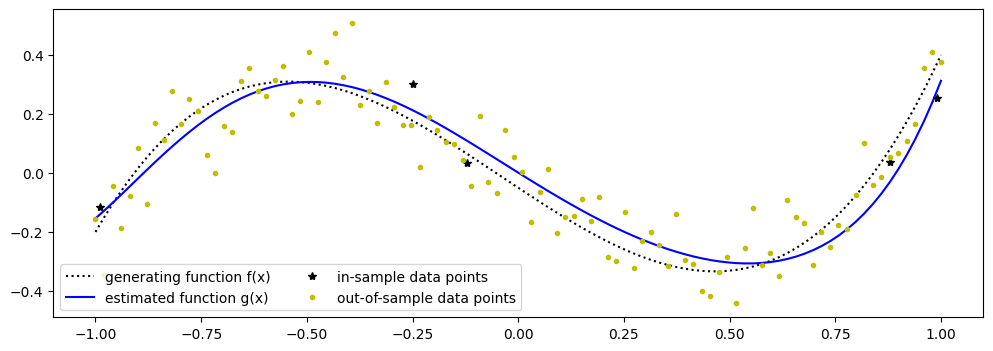

In [11]:
# Exercise #2 (continuation): perform a linear regression by using the optimal set of predictors encountered

# add your code here...
best_row = best_by_size.loc[best_by_size['out_error'].idxmin()]
best_subset = best_row['variables']
print('Optimal subset of predictors:',best_row['model'],'\n')

model_select = do_regression(data,best_subset,verbose=True,plot=True)


In [12]:
# How results in exercise #2 compare to the ones presented in exercise #1? Does the model overfits the data?
# <The out-of-sample error drops by about a factor of 5 with respect to exercise #1 (~0.009300 vs ~0.046866), while the in-sample error is no longer zero (~0.003793). The model does NOT overfit anymore: Ein and Eout are now of the same order of magnitude, which is the definition of generalization. Cutting the degrees of freedom from 8 to 4 removed exactly the freedom that was being spent on fitting the noise, and g(x) now follows f(x) closely over the whole range.>

In [13]:
# Exercise #3: implement a loop for computing linear regressions on transformed sets of predictors {zm}.
# More sepecifically, consider the sets {z1}, {z1,z2}, ... {z1,z2,...z7}. Use PCA for deriving the
# transformed predictos {zm} from the subset of original predictors {p1,p2,...p7} (i.e. exclude P0).
# Present the resuts in a similar tabular form as it was done in exercise #2.
# Suggestion: use all data avaiable (in-sample and out-of-sample) to learn the PCA projections!

# add your code here...
pca_vars = [v for v in allvars if v!='p0']
full_X = np.concatenate((data[0][pca_vars].to_numpy(),data[1][pca_vars].to_numpy()),axis=0)
pca = PCA(n_components=len(pca_vars)).fit(full_X)
znames = ['z'+str(m+1) for m in range(len(pca_vars))]
print('explained variance ratio:',np.round(pca.explained_variance_ratio_,6))

# add the transformed predictors {zm} as new columns of both dataframes
zdata = []
for k in range(2):
    df = data[k].copy()
    df[znames] = pca.transform(data[k][pca_vars].to_numpy())
    zdata.append(df)

models_pca = []
for m in tqdm(range(1,len(znames)+1)):
    subset = znames[:m]
    r = do_regression(zdata,subset)
    models_pca.append({'model':'{'+', '.join(subset)+'}',
                       '#predictors':m,
                       'in_error':r['in_error'],
                       'out_error':r['out_error'],
                       'out_r2':r['out_r2'],
                       'variables':subset})

models_pca = pd.DataFrame(models_pca)
models_pca[['model','#predictors','in_error','out_error','out_r2']]



explained variance ratio: [0.310393 0.201895 0.148577 0.112555 0.091565 0.072342 0.062673]


100%|██████████| 7/7 [00:00<00:00, 112.65it/s]


,model,#predictors,in_error,out_error,out_r2
0,{z1},1,2.506840e-02,0.067567,-0.229433
1,"{z1, z2}",2,2.505077e-02,0.067770,-0.233115
2,"{z1, z2, z3}",3,1.075339e-02,0.016139,0.706348
3,"{z1, z2, z3, z4}",4,1.053477e-02,0.025453,0.536857
4,"{z1, z2, z3, z4, z5}",5,6.379643e-32,0.118445,-1.155187
5,"{z1, z2, z3, z4, z5, z6}",6,1.151706e-32,0.033331,0.393519
6,"{z1, z2, z3, z4, z5, z6, z7}",7,5.638930e-31,0.037309,0.321139


In [14]:
# Based in your results from exercise #3, what is the best model?
# <The best model is the one with the smallest out-of-sample error, {z1, z2, z3} (S = 3, Eout ~0.016139), which is also the value reported in class. It makes sense: the explained variance ratio shows that the first three principal components already account for almost all the variance of {p1...p7}, so the remaining components mostly add freedom to fit noise rather than useful information.>

Optimal set of transformed predictors: {z1, z2, z3} ( S = 3 )

Linear Regression (alpha = 0.0)
       Coefficients: -0.109089, 0.042153, 0.328775
          Intercept: 0.0
    In-sample Error: 0.010753392629453937
Out-of-sample Error: 0.01613856262445114
   Out-of-sample R2: 0.7063482483294287


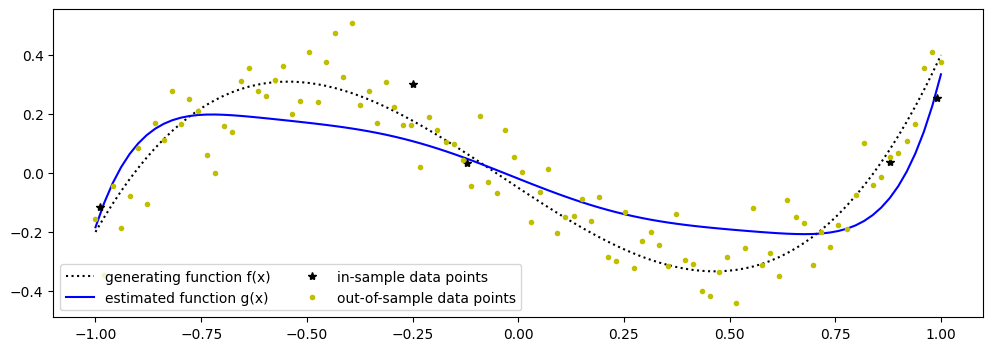

In [15]:
# Exercise #3 (continuation): perform a linear regression by using the optimal set of transformed predictors

# add your code here...
best_pca = models_pca.loc[models_pca['out_error'].idxmin()]
print('Optimal set of transformed predictors:',best_pca['model'],'( S =',best_pca['#predictors'],')\n')

model_pca = do_regression(zdata,best_pca['variables'],verbose=True,plot=True)


In [16]:
# How results in exercise #3 compare to the ones presented in exercises #1 and #2? Does the model overfits the data?
# <Clearly better than exercise #1 (Eout ~0.016138 vs ~0.046866) but worse than exercise #2 (~0.009300). No overfitting: Ein (~0.010753) and Eout (~0.016138) are very close. If anything the model slightly underfits, and g(x) is visibly flatter than f(x). Reason: PCA selects the directions of largest variance among the predictors, which are not necessarily the directions most correlated with the target, so it is less effective than best subset selection but far cheaper (7 models instead of 255) and it uses no information about y at all.>

## PART 2: Regularization Methods

100%|██████████| 50/50 [00:00<00:00, 251.84it/s]


Optimal shrinkage factor: lambda = 0.05
Minimum out-of-sample error: 0.035753423806497396


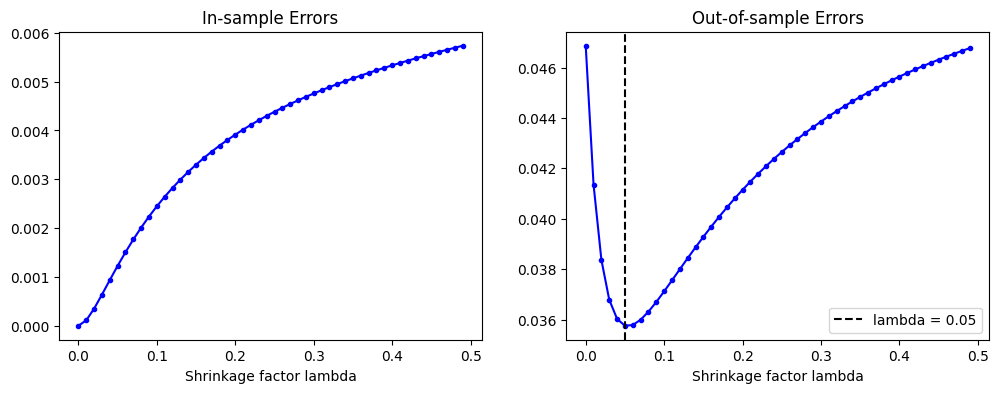

In [17]:
# Exercise #4: implement a loop to evaluate the performance of ridge regression along different values
# of the shrinkage factor alpha (lambda as used in class!). Generate plots for both the in-sample and
# the out-of-sample errors vs the shrinkage factor value. Use the suggested value list!

# Suggested values for the shrinkage factor
lambdas = [k/100 for k in range(50)]

# add your code here...
ridge_runs = [do_regression(data,allvars,'ridge',a) for a in tqdm(lambdas)]
ridge_in  = [r['in_error']  for r in ridge_runs]
ridge_out = [r['out_error'] for r in ridge_runs]

best_ridge_alpha = lambdas[int(np.argmin(ridge_out))]
print('Optimal shrinkage factor: lambda =',best_ridge_alpha)
print('Minimum out-of-sample error:',min(ridge_out))

fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(lambdas,ridge_in,'.-b')
ax[0].set_title('In-sample Errors')
ax[1].plot(lambdas,ridge_out,'.-b')
ax[1].set_title('Out-of-sample Errors')
ax[1].axvline(best_ridge_alpha,ls='--',c='k',label='lambda = '+str(best_ridge_alpha))
ax[1].legend()
for a in ax:
    a.set_xlabel('Shrinkage factor lambda')
plt.show()


In [18]:
# How results in exercise #4 compare to the ones presented in class? What lambda value is providing best results?
# <Same behaviour as in class: the in-sample error grows monotonically with lambda (the penalty keeps the model from fitting the data), while the out-of-sample error falls very quickly, reaches a minimum and then grows again. The best value is lambda = 0.05, with Eout ~0.035753, an improvement over the unregularized baseline (~0.046866). This is the bias-variance trade-off: too little shrinkage leaves variance (overfitting), too much shrinkage introduces bias (underfitting).>

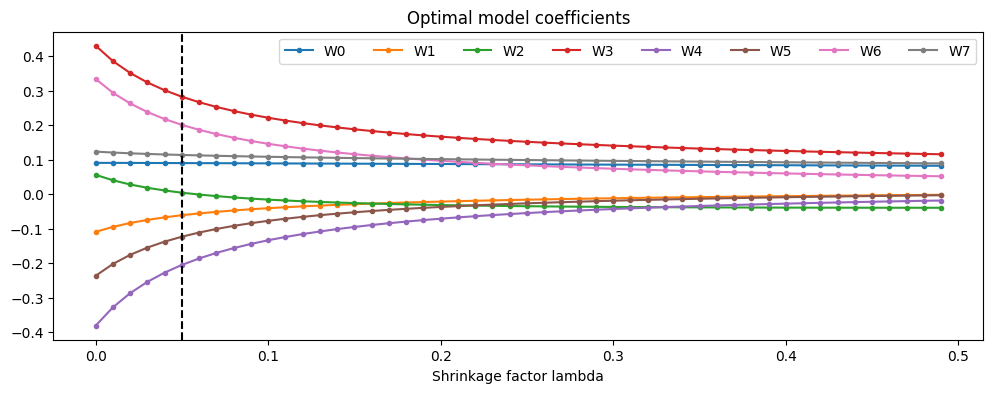

In [19]:
# Exercise #4 (continuation): generate a plot showing all eight regression coefficients vs the shrinkage factor

# add your code here...
ridge_coefs = np.array([r['coefficients'] for r in ridge_runs])

fig, ax = plt.subplots(1,1,figsize=(12,4))
for k in range(ridge_coefs.shape[1]):
    ax.plot(lambdas,ridge_coefs[:,k],'.-',label='W'+str(k))
ax.axvline(best_ridge_alpha,ls='--',c='k')
ax.set_title('Optimal model coefficients')
ax.set_xlabel('Shrinkage factor lambda')
ax.legend(ncol=8)
plt.show()


In [20]:
# What would be your main observations from the plot? How your results compare to the ones presented in class?
# <Same behaviour as in class: the in-sample error grows monotonically with lambda (the penalty keeps the model from fitting the data), while the out-of-sample error falls very quickly, reaches a minimum and then grows again. The best value is lambda = 0.05, with Eout ~0.035753, an improvement over the unregularized baseline (~0.046866). This is the bias-variance trade-off: too little shrinkage leaves variance (overfitting), too much shrinkage introduces bias (underfitting).>

Ridge Regression (alpha = 0.05)
       Coefficients: 0.090323, -0.060712, 0.004511, 0.282526, -0.204713, -0.122949, 0.201000, 0.113827
          Intercept: 0.0
    In-sample Error: 0.0012280952119657592
Out-of-sample Error: 0.035753423806497396
   Out-of-sample R2: 0.3494429601127299


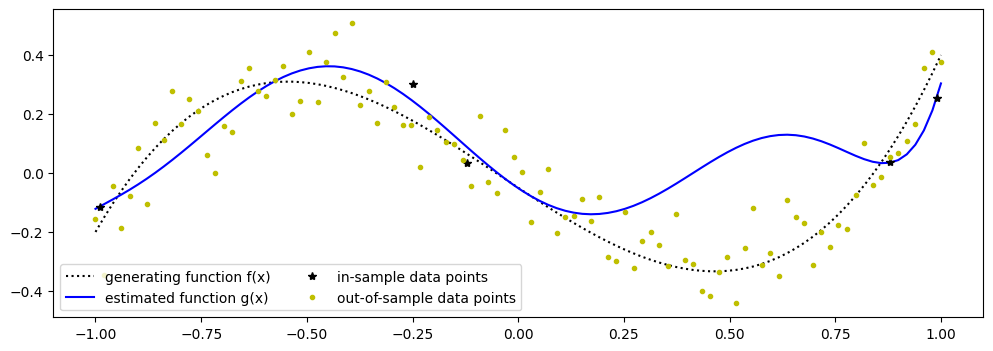

In [21]:
# Exercise #4 (continuation): perform a ridge regression by using the optimal shrinkage factor found

# add your code here...
model_ridge = do_regression(data,allvars,'ridge',best_ridge_alpha,verbose=True,plot=True)



In [22]:
# How results in exercise #4 compare to the ones in exercises #1, #2 and #3? What are your main conclusions?
# <Ridge (Eout ~0.035753) improves on the baseline of exercise #1 (~0.046866), but is clearly worse than best subset selection in exercise #2 (~0.009300) and than PCA in exercise #3 (~0.016138). Its very small in-sample error (~0.001228) shows that a good part of the overfitting is still there. Conclusion: with 5 points and 8 predictors, shrinking every coefficient a little is not enough, because the irrelevant predictors keep contributing. Removing degrees of freedom beats penalizing them uniformly.>

100%|██████████| 50/50 [00:00<00:00, 256.32it/s]


Optimal shrinkage factor: lambda = 0.003
Minimum out-of-sample error: 0.011235201938249935


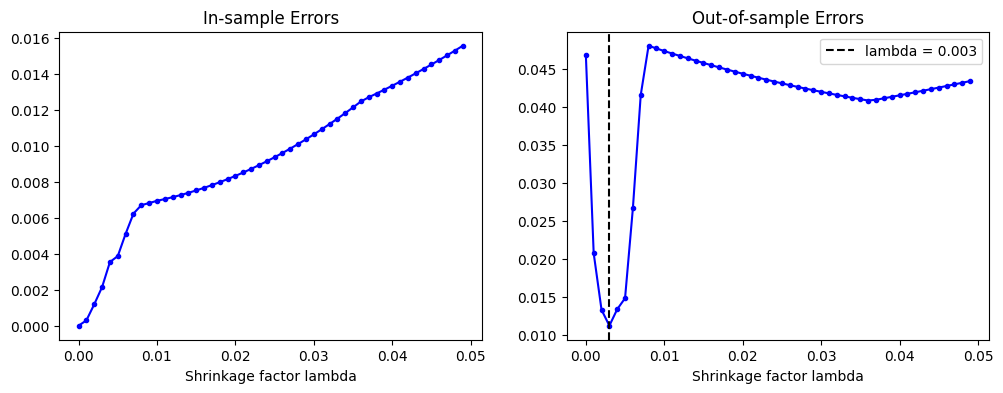

In [23]:
# Exercise #5: implement a loop to evaluate the performance of lasso regression along different values
# of the shrinkage factor alpha (lambda as used in class!). Generate plots for both the in-sample and
# the out-of-sample errors vs the shrinkage factor value. Use the suggested value list!

# Suggested values for the shrinkage factor
lambdas = [k/1000 for k in range(50)]

# add your code here...
# lasso is solved by coordinate descent; convergence warnings for the smallest lambdas are harmless
import warnings
warnings.filterwarnings('ignore')

lasso_runs = [do_regression(data,allvars,'lasso',a) for a in tqdm(lambdas)]
lasso_in  = [r['in_error']  for r in lasso_runs]
lasso_out = [r['out_error'] for r in lasso_runs]

best_lasso_alpha = lambdas[int(np.argmin(lasso_out))]
print('Optimal shrinkage factor: lambda =',best_lasso_alpha)
print('Minimum out-of-sample error:',min(lasso_out))

fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(lambdas,lasso_in,'.-b')
ax[0].set_title('In-sample Errors')
ax[1].plot(lambdas,lasso_out,'.-b')
ax[1].set_title('Out-of-sample Errors')
ax[1].axvline(best_lasso_alpha,ls='--',c='k',label='lambda = '+str(best_lasso_alpha))
ax[1].legend()
for a in ax:
    a.set_xlabel('Shrinkage factor lambda')
plt.show()


In [24]:
# How results in exercise #5 compare to the ones presented in class? What lambda value is providing best results?
# <Same behaviour as in class: Ein grows with lambda and Eout shows a very sharp minimum at lambda = 0.003, with Eout ~0.011235. Two differences with respect to ridge: the minimum is much deeper (0.011 vs 0.036), and the Eout curve is far less smooth it collapses and jumps back up within a couple of steps, so lasso is much more sensitive to the choice of lambda and the grid has to be finer (k/1000 instead of k/100).>

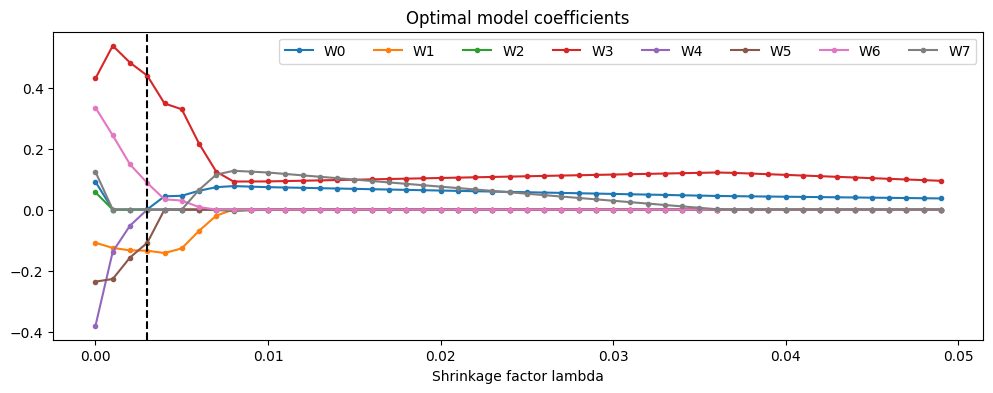

Number of non-zero coefficients per lambda: [8 5 5 5 4 4 5 5 4 4 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [25]:
# Exercise #5 (continuation): generate a plot showing all eight regression coefficients vs the shrinkage factor

# add your code here...
lasso_coefs = np.array([r['coefficients'] for r in lasso_runs])

fig, ax = plt.subplots(1,1,figsize=(12,4))
for k in range(lasso_coefs.shape[1]):
    ax.plot(lambdas,lasso_coefs[:,k],'.-',label='W'+str(k))
ax.axvline(best_lasso_alpha,ls='--',c='k')
ax.set_title('Optimal model coefficients')
ax.set_xlabel('Shrinkage factor lambda')
ax.legend(ncol=8)
plt.show()

print('Number of non-zero coefficients per lambda:',np.sum(lasso_coefs!=0,axis=1))


In [26]:
# What would be your main observations from the plot? How your results compare to the ones presented in class?
# <Unlike ridge, the coefficients are driven exactly to zero, one after another, as lambda grows, and they do not decrease monotonically (some grow first before being switched off). At the optimum only a few of the eight predictors survive. This is the key property of L1: it performs shrinkage AND variable selection at the same time, so lasso behaves like a continuous, automatic version of subset selection. Same as presented in class.>

Lasso Regression (alpha = 0.003)
       Coefficients: 0.000539, -0.134740, -0.000000, 0.439146, -0.000000, -0.108832, 0.087267, 0.000000
          Intercept: 0.0
    In-sample Error: 0.002147720343054393
Out-of-sample Error: 0.011235201938249935
   Out-of-sample R2: 0.795568118034186

Non-zero coefficients: 5 out of 8
Predictors selected by lasso: ['p0', 'p1', 'p3', 'p5', 'p6']


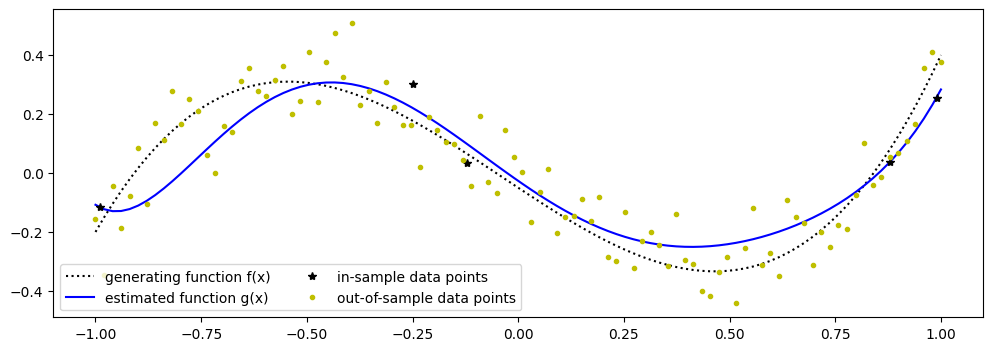

In [27]:
# Exercise #5 (continuation): perform a lasso regression by using the optimal shrinkage factor found

# add your code here...
model_lasso = do_regression(data,allvars,'lasso',best_lasso_alpha,verbose=True,plot=True)

print('\nNon-zero coefficients:',int(np.sum(model_lasso['coefficients']!=0)),'out of',len(allvars))
print('Predictors selected by lasso:',[allvars[k] for k in range(len(allvars)) if model_lasso['coefficients'][k]!=0])


In [28]:
# How results in exercise #5 compare to the ones in exercises #1, #2, #3 and #4? What are your main conclusions?
# <Ranking by out-of-sample error: select (~0.0093) < lasso (~0.0112) < pca (~0.0161) < ridge (~0.0358) < baseline (~0.0469). Lasso is essentially as good as exhaustive best subset selection while training only 50 models instead of 255, because L1 finds the sparse solution by itself. Main conclusion: on a small and noisy dataset what pays off is reducing the effective number of degrees of freedom lasso does it implicitly by zeroing coefficients, ridge only rescales them and therefore helps much less.>

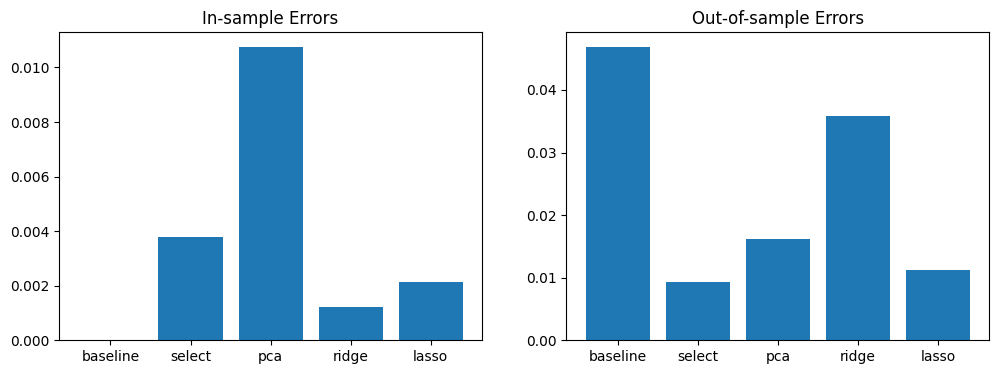

,model,in_error,out_error,out_r2
0,baseline,8.228536e-32,0.046866,0.147242
1,select,3.793522e-03,0.009300,0.830774
2,pca,1.075339e-02,0.016139,0.706348
3,ridge,1.228095e-03,0.035753,0.349443
4,lasso,2.147720e-03,0.011235,0.795568


In [29]:
# Exercise #6: generate two bar plots (one for in-sample error and the other for out-of-sample error)
# comparing the models derived in exercises #1, #2, #3, #4, and #5

# add your code here...
names  = ['baseline','select','pca','ridge','lasso']
models = [model_baseline,model_select,model_pca,model_ridge,model_lasso]
in_errors  = [m['in_error']  for m in models]
out_errors = [m['out_error'] for m in models]

fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].bar(names,in_errors)
ax[0].set_title('In-sample Errors')
ax[1].bar(names,out_errors)
ax[1].set_title('Out-of-sample Errors')
plt.show()

pd.DataFrame({'model':names,'in_error':in_errors,'out_error':out_errors,
              'out_r2':[m['out_r2'] for m in models]})


In [30]:
# What are your main conclusions from exercise #6 results?
# <The two bar plots are almost mirror images of each other: the models with the smallest in-sample error (baseline, ridge) are the ones with the largest out-of-sample error, and the models with the largest in-sample error (pca, select) are among the best generalizers. Both plots reproduce the summary shown in class.
# Main conclusion: a small in-sample error is not evidence of learning, only Eout tells whether the
# model generalizes. Best compromise here: best subset selection and lasso.>

## PART 3: Applying Cross-validation

In [31]:
# Consider the diabetes dataset provided within scikit learn
from sklearn.datasets import load_diabetes
data = load_diabetes()
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [32]:
# Let us push predictors and target into a dataframe and perform a zero-mean untiary-variance normalization
datamtx = np.concatenate((data.data,data.target.reshape(-1,1)),axis=1)
datafrm = pd.DataFrame(data=datamtx,columns=data.feature_names+['targets'])
datafrm = (datafrm-datafrm.mean())/datafrm.std()
datafrm.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,targets
0,0.799594,1.064282,1.295620,0.459320,-0.928693,-0.731236,-0.911418,-0.054438,0.418057,-0.370569,-0.014703
1,-0.039522,-0.937474,-1.080955,-0.552878,-0.177423,-0.402430,1.562643,-0.829361,-1.434962,-1.936285,-1.000525
2,1.791277,1.064282,0.933475,-0.119079,-0.957588,-0.718084,-0.679475,-0.054438,0.060087,-0.544537,-0.144416
3,-1.870322,-0.937474,-0.243495,-0.769778,0.256002,0.524802,-0.756789,0.720486,0.476443,-0.196600,0.698721
4,0.113044,-0.937474,-0.764079,0.459320,0.082632,0.327519,0.170984,-0.054438,-0.671740,-0.979458,-0.222244


In [39]:
# Exercise 7: here we use the RidgeCV class in scikit learn, which performs leave-one-out cross-validation
# and uses the optimal shrinkage factor to train a Ridge Regression model. You should read the corresponding
# documentation in: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html, and
# get familiar with RidgeCV. Then, conduct the following steps:
# 1.- select a random sample of 30 data points as in-sample data
# 2.- select a random sample of 300 data points as out-of-sample data
# 3.- conduct a standard linear regression (use the fit method in LinearRegression)
# 3.a.- compute the in-sample coefficient of determination R2 (use the score method)
# 3.b.- compute the out-sample coefficient of determination R2 (use the score method)
# 4.- conduct a ridge regression with leave-one-out cross-validation (use the fit method in RidgeCV)
# 4.a.- consider the follwing values for the shrinkage factor [x/50 for x in range(1,5000)]
# 4.b.- make sure the resulting shrinkage factor is inside the provided range (otherwise ingnore the result)
# 4.c.- compute the in-sample coefficient of determination R2 (use the score method)
# 4.d.- compute the out-sample coefficient of determination R2 (use the score method)
# 5.- repeat steps 1 to 4 a significant number of times (~100)
# 6.- report means and standard deviations for the in-sample and out-of-sampe R2s in both regressions

from sklearn.linear_model import RidgeCV
lambdas = [x/50 for x in range(1,5000)]

# add your code here...

features = [c for c in datafrm.columns if c!='targets']
n_trials = 100
in_size, out_size = 30, 300

res = {'lin_in':[],'lin_out':[],'rdg_in':[],'rdg_out':[],'alpha':[]}

for t in tqdm(range(n_trials)):                                  # 5: repeat the experiment 100 times
    # 1 and 2: random (and disjoint) in-sample and out-of-sample subsets
    sample   = datafrm.sample(n=in_size+out_size,replace=False)
    in_data  = sample.iloc[:in_size]
    out_data = sample.iloc[in_size:]
    in_X,  in_Y  = in_data[features].to_numpy(),  in_data['targets'].to_numpy()
    out_X, out_Y = out_data[features].to_numpy(), out_data['targets'].to_numpy()

    # 3: standard linear regression
    lin = LinearRegression().fit(in_X,in_Y)

    # 4: ridge regression, cv=None makes RidgeCV use efficient leave-one-out cross-validation
    rdg = RidgeCV(alphas=lambdas).fit(in_X,in_Y)                 # 4.a: shrinkage factors from lambdas
    if not (lambdas[0] < rdg.alpha_ < lambdas[-1]):              # 4.b: discard boundary solutions
        continue

    res['lin_in'].append(lin.score(in_X,in_Y))                   # 3.a
    res['lin_out'].append(lin.score(out_X,out_Y))                # 3.b
    res['rdg_in'].append(rdg.score(in_X,in_Y))                   # 4.c
    res['rdg_out'].append(rdg.score(out_X,out_Y))                # 4.d
    res['alpha'].append(rdg.alpha_)

res = {k:np.array(v) for k,v in res.items()}
print('Valid trials:',len(res['lin_in']),'of',n_trials,'  mean optimal lambda:',round(res['alpha'].mean(),3),'\n')

# 6: means and standard deviations of the in- and out-of-sample R2 for both regressions
pd.DataFrame({'regression':['baseline','baseline','ridge','ridge'],
              'R2':['in-sample','out-of-sample','in-sample','out-of-sample'],
              'mean':[res['lin_in'].mean(),res['lin_out'].mean(),
                      res['rdg_in'].mean(),res['rdg_out'].mean()],
              'std' :[res['lin_in'].std(),res['lin_out'].std(),
                      res['rdg_in'].std(),res['rdg_out'].std()]})


100%|██████████| 100/100 [00:35<00:00,  2.84it/s]

Valid trials: 99 of 100   mean optimal lambda: 18.505 



,regression,R2,mean,std
0,baseline,in-sample,0.655313,0.105420
1,baseline,out-of-sample,0.213934,0.190483
2,ridge,in-sample,0.578293,0.134927
3,ridge,out-of-sample,0.368285,0.072004


In [34]:
# What are your main observations from exercise #7 results? Are you observing overfitting? Does Ridge help?
# <Yes, baseline regression overfits: in-sample R² = 0.6553 but out-of-sample R² = 0.2139 with high
# std (0.1905). Ridge regression improves generalization by sacrificing in-sample R² (0.5783) to nearly
# double out-of-sample R² (0.3683) and reduce std (0.0720). This demonstrates the bias-variance trade-off:
# ridge reduces variance at the cost of small bias increase, yielding more stable predictions. The optimal
# lambda ≈ 18.505 found by leave-one-out cross-validation balances these objectives effectively.>

In [40]:
# Exercise 8: reuse your code from exercise #7 and implement a loop for comparing baseline and Ridge regression
# performances for different in-sample data sizes. Again, report means and standard deviations for the in-sample
# and out-of-sampe R2s in both, baseline and Ridge, regressions.

from sklearn.linear_model import RidgeCV
lambdas = [x/50 for x in range(1,5000)]
in_sample_sizes = [20,30,40,50,60,70,80,90,100]

# add your code here...
out_size = 300
n_trials = 100

def compare_regressions(in_size,out_size=300,n_trials=100):
    # same experiment as exercise #7, for a given in-sample size
    res = {'lin_in':[],'lin_out':[],'rdg_in':[],'rdg_out':[]}
    for t in range(n_trials):
        sample   = datafrm.sample(n=in_size+out_size,replace=False)
        in_data  = sample.iloc[:in_size]
        out_data = sample.iloc[in_size:]
        in_X,  in_Y  = in_data[features].to_numpy(),  in_data['targets'].to_numpy()
        out_X, out_Y = out_data[features].to_numpy(), out_data['targets'].to_numpy()

        lin = LinearRegression().fit(in_X,in_Y)
        rdg = RidgeCV(alphas=lambdas).fit(in_X,in_Y)
        if not (lambdas[0] < rdg.alpha_ < lambdas[-1]):
            continue

        res['lin_in'].append(lin.score(in_X,in_Y))
        res['lin_out'].append(lin.score(out_X,out_Y))
        res['rdg_in'].append(rdg.score(in_X,in_Y))
        res['rdg_out'].append(rdg.score(out_X,out_Y))
    return {k:np.array(v) for k,v in res.items()}

rows = []
for n in tqdm(in_sample_sizes):
    r = compare_regressions(n,out_size,n_trials)
    rows.append({'in_size':n,'valid':len(r['lin_in']),
                 'base_in_mean' :r['lin_in'].mean(),  'base_in_std' :r['lin_in'].std(),
                 'base_out_mean':r['lin_out'].mean(), 'base_out_std':r['lin_out'].std(),
                 'ridge_in_mean':r['rdg_in'].mean(),  'ridge_in_std':r['rdg_in'].std(),
                 'ridge_out_mean':r['rdg_out'].mean(),'ridge_out_std':r['rdg_out'].std()})

cv_results = pd.DataFrame(rows)
cv_results.round(4)


100%|██████████| 9/9 [04:16<00:00, 28.52s/it]


,in_size,valid,base_in_mean,base_in_std,base_out_mean,base_out_std,ridge_in_mean,ridge_in_std,ridge_out_mean,ridge_out_std
0,20,97,0.7595,0.0864,-0.4569,1.5169,0.6262,0.1588,0.2684,0.2316
1,30,95,0.6825,0.0929,0.1562,0.2208,0.6112,0.1256,0.3733,0.0761
2,40,100,0.6222,0.0930,0.2910,0.1351,0.5687,0.1141,0.3936,0.0638
3,50,99,0.5957,0.0754,0.3645,0.0806,0.5579,0.0856,0.4145,0.0526
4,60,99,0.5795,0.0662,0.3971,0.0633,0.5505,0.0742,0.4324,0.0455
5,70,100,0.5928,0.0697,0.4032,0.0553,0.5725,0.0762,0.4342,0.0461
6,80,100,0.5599,0.0727,0.4179,0.0493,0.5395,0.0774,0.4443,0.0351
7,90,98,0.5534,0.0539,0.4411,0.0411,0.5366,0.0574,0.4578,0.0291
8,100,100,0.5546,0.0489,0.4498,0.0371,0.5412,0.0512,0.4629,0.0288


In [36]:
# What are your main observations from exercise #8 results?
# < Overfitting severity decreases dramatically with more data. At N=20, baseline out-of-sample R² is
# negative (-0.457) with huge std (1.517), indicating complete failure. By N=100, it reaches 0.450
# with std 0.037, showing convergence. Ridge consistently outperforms baseline, especially when data
# is scarce: at N=20 ridge achieves 0.268 (vs baseline -0.457), and maintains higher out-of-sample R²
# across all sizes. The overfitting advantage of ridge peaks at N=20-40 (gap ~0.7) and nearly vanishes
# by N=100 (gap ~0.013). Both methods show decreasing std as N grows, but ridge's std stays 3-8× lower,
# confirming that regularization is a substitute for data: essential when data is scarce, less critical
# when abundant.>

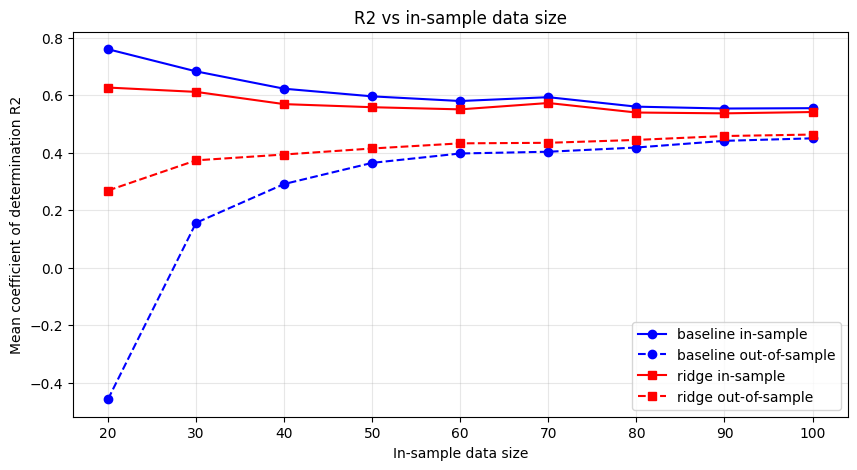

In [41]:
# Exercise #8 (continuation): produce a plot ilustrating the behavior of mean in-sample and out-of-sample
# coefficient of determination R2 vs in-sample data size for both, baseline and Ridge, regressions.

# add your code here...
fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(cv_results['in_size'],cv_results['base_in_mean'],'o-b',label='baseline in-sample')
ax.plot(cv_results['in_size'],cv_results['base_out_mean'],'o--b',label='baseline out-of-sample')
ax.plot(cv_results['in_size'],cv_results['ridge_in_mean'],'s-r',label='ridge in-sample')
ax.plot(cv_results['in_size'],cv_results['ridge_out_mean'],'s--r',label='ridge out-of-sample')
ax.set_xlabel('In-sample data size')
ax.set_ylabel('Mean coefficient of determination R2')
ax.set_title('R2 vs in-sample data size')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


In [38]:
# What are your main observations from exercise #8 results? Where are you observing overfitting? Does Ridge help?
# <The plot reproduces the "sample complexity and overfitting" figure from class: the in-sample curve
# decreases, the out-of-sample curve increases, and the two converge as the in-sample size grows.
# Overfitting is where the vertical gap between the two curves of the same model is large, i.e. at small
# in-sample sizes (N=20-40); it becomes marginal from N~80 on.
# Ridge helps precisely in that region: its out-of-sample curve sits well above the baseline one for
# small N, while both merge for large N. In other words, regularization is a substitute for data - once
# enough data is available it is no longer needed.>